In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report)

In [ ]:
iris = load_iris()

In [ ]:
X,y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [ ]:
classifier_default = DecisionTreeClassifier(max_depth=None, criterion='gini', random_state=42)
classifier_default.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
predictions_default = classifier_default.predict(X_test)

In [ ]:
print(f"Default Model Accuracy: {accuracy_score(y_test, predictions_default):.4f}\n")

Default Model Accuracy: 1.0000



In [ ]:
print(f"Default Decision Tree Model Evaluation\n")
print(f"Accuracy: {accuracy_score(y_test, predictions_default):.4f}")
print(f"Precision (Macro): {precision_score(y_test, predictions_default, average='macro'):.4f}")
print(f"Recall (Macro): {recall_score(y_test, predictions_default, average='macro'):.4f}")
print(f"F1-Score (Macro): {f1_score(y_test, predictions_default, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions_default, target_names=target_names))

Default Decision Tree Model Evaluation

Accuracy: 1.0000
Precision (Macro): 1.0000
Recall (Macro): 1.0000
F1-Score (Macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



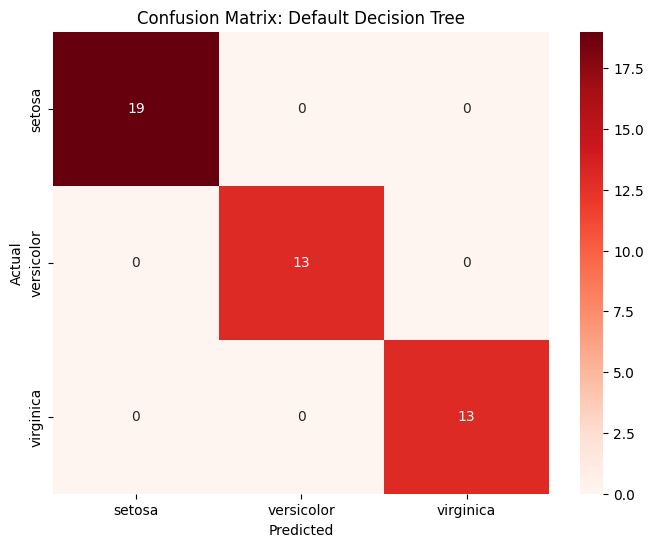

In [27]:
# Confusion Matrix
cm = confusion_matrix(y_test, predictions_default)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Default Decision Tree')
plt.show()

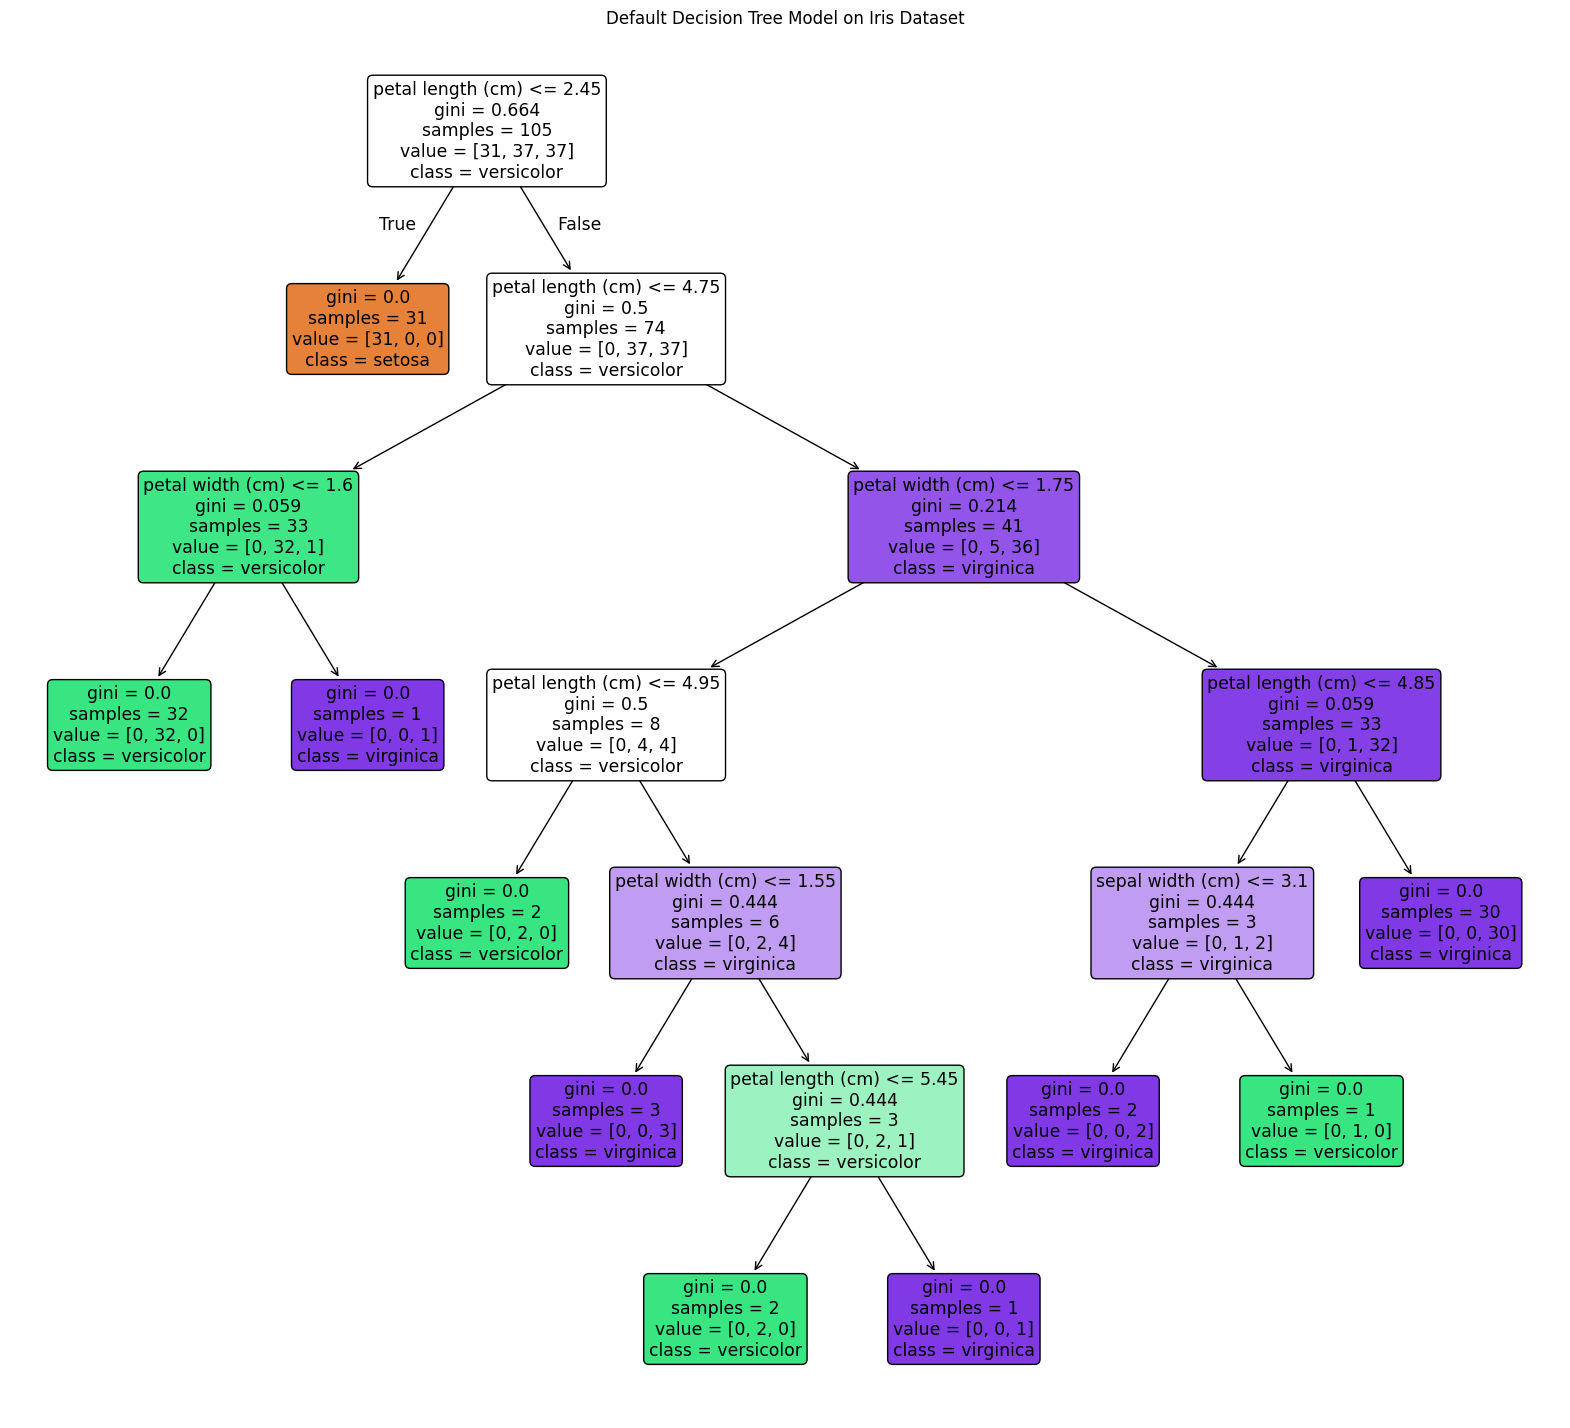

In [ ]:
# Visualize the tree
plt.figure(figsize=(20, 18))
plot_tree(classifier_default, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title("Default Decision Tree Model on Iris Dataset")
plt.show()

Hyperparameters Tuning

In [ ]:
depths = [2, 3, 4, 5]
criteria = ["gini", "entropy"]
min_splits = [2, 4]

In [ ]:
best_score = 0
best_params = {}

In [ ]:
print("Hyperparameter Tuning Results\n")
for d in depths:
    for c in criteria:
        for s in min_splits:
            clf = DecisionTreeClassifier(max_depth=d, criterion=c, min_samples_split=s, random_state=42)
            clf.fit(X_train, y_train)
            score = accuracy_score(y_test, clf.predict(X_test))

            print(f"Depth: {d}, Criterion: {c}, Min Split: {s} | Accuracy: {score:.4f}")

            if score > best_score:
                best_score = score
                best_params = {'max_depth': d, 'criterion': c, 'min_samples_split': s}

print(f"\nBest Parameters Found: {best_params} with Accuracy: {best_score:.4f}")

Hyperparameter Tuning Results

Depth: 2, Criterion: gini, Min Split: 2 | Accuracy: 0.9778
Depth: 2, Criterion: gini, Min Split: 4 | Accuracy: 0.9778
Depth: 2, Criterion: entropy, Min Split: 2 | Accuracy: 0.9778
Depth: 2, Criterion: entropy, Min Split: 4 | Accuracy: 0.9778
Depth: 3, Criterion: gini, Min Split: 2 | Accuracy: 1.0000
Depth: 3, Criterion: gini, Min Split: 4 | Accuracy: 1.0000
Depth: 3, Criterion: entropy, Min Split: 2 | Accuracy: 0.9778
Depth: 3, Criterion: entropy, Min Split: 4 | Accuracy: 0.9778
Depth: 4, Criterion: gini, Min Split: 2 | Accuracy: 1.0000
Depth: 4, Criterion: gini, Min Split: 4 | Accuracy: 1.0000
Depth: 4, Criterion: entropy, Min Split: 2 | Accuracy: 1.0000
Depth: 4, Criterion: entropy, Min Split: 4 | Accuracy: 1.0000
Depth: 5, Criterion: gini, Min Split: 2 | Accuracy: 1.0000
Depth: 5, Criterion: gini, Min Split: 4 | Accuracy: 1.0000
Depth: 5, Criterion: entropy, Min Split: 2 | Accuracy: 0.9778
Depth: 5, Criterion: entropy, Min Split: 4 | Accuracy: 0.9778



In [ ]:
# 4. Model Evaluation (Best Model)
best_classifier = DecisionTreeClassifier(**best_params, random_state=42)
best_classifier.fit(X_train, y_train)
y_pred = best_classifier.predict(X_test)

In [ ]:
# Metrics
print("Final Decision Tree Model Evaluation\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (Macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (Macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-Score (Macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(classification_report(y_test, y_pred, target_names=target_names))

Final Decision Tree Model Evaluation

Accuracy: 1.0000
Precision (Macro): 1.0000
Recall (Macro): 1.0000
F1-Score (Macro): 1.0000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



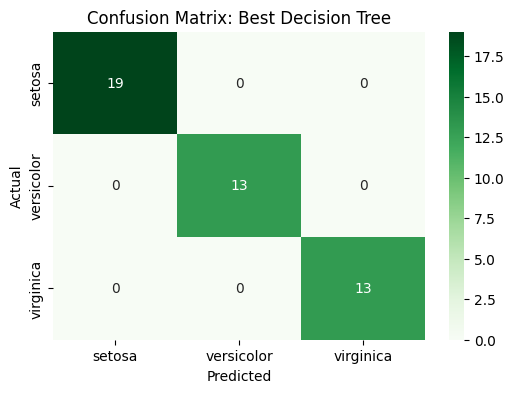

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Best Decision Tree')
plt.show()

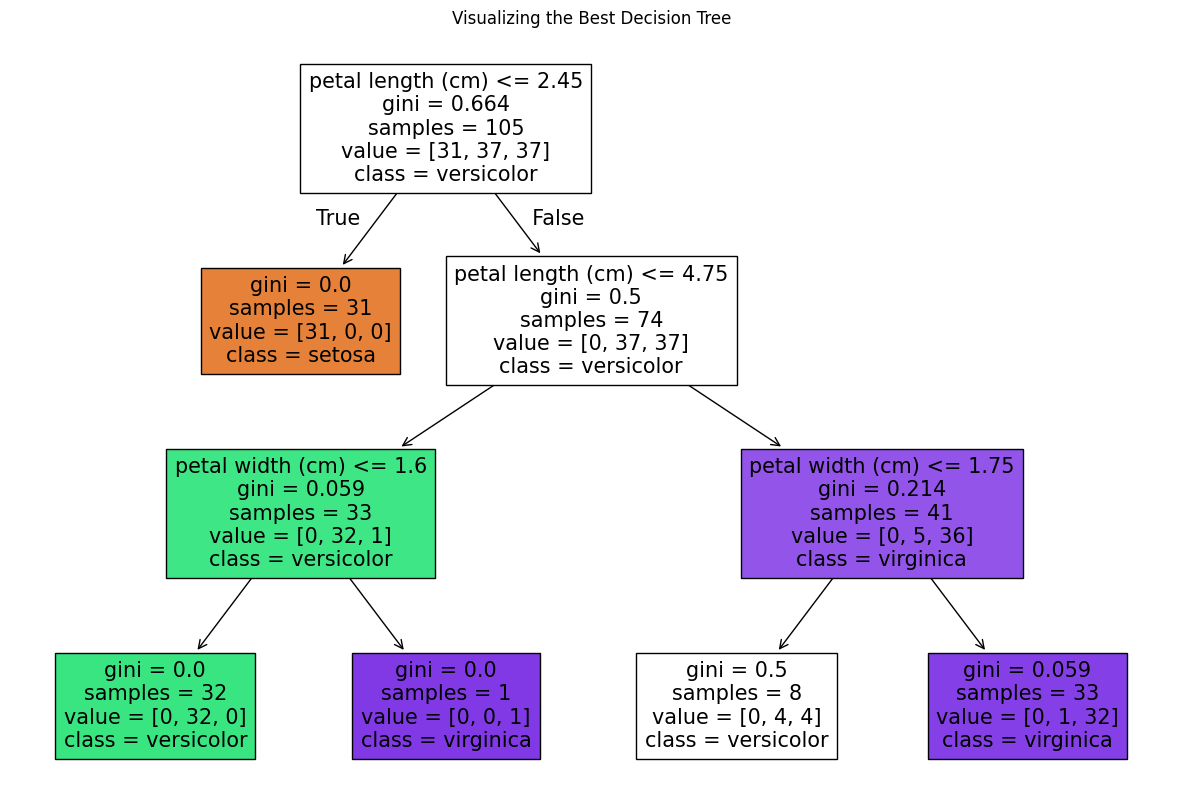

In [ ]:
plt.figure(figsize=(15,10))
plot_tree(best_classifier, feature_names=feature_names, class_names=target_names, filled=True)
plt.title("Visualizing the Best Decision Tree")
plt.show()